<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/complete_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Complete Efficient ML System

This notebook brings together all of ML efficiency techniques into a complete,  system. I attempt to build an end-to-end pipeline that:

1. Trains an efficient architecture with all optimizations
2. Compresses via pruning, quantization, and distillation
3. Analyzes efficiency across all dimensions
4. Deploys with optimized inference
5. Reports comprehensive metrics and recommendations


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Tuple, Callable, Any
from dataclasses import dataclass, field
from collections import OrderedDict
import copy
import time
import json
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"="*60)
print(f" Complete Efficient ML System")
print(f"="*60)
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

 Complete Efficient ML System
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


Setup & Configuration

In [3]:
@dataclass
class SystemConfig:
    """Complete system configuration."""
    # Data
    dataset: str = 'cifar10'
    batch_size: int = 128
    num_workers: int = 2

    # Model
    model_type: str = 'efficientnet'  # 'resnet', 'mobilenet', 'efficientnet'
    num_classes: int = 10

    # Training
    epochs: int = 15
    lr: float = 0.1
    momentum: float = 0.9
    weight_decay: float = 5e-4
    label_smoothing: float = 0.1

    # Efficiency
    use_amp: bool = True
    use_onecycle: bool = True
    gradient_clip: float = 1.0

    # Compression
    prune_amount: float = 0.3
    quantize: bool = True
    distill: bool = True
    distill_temperature: float = 4.0
    distill_alpha: float = 0.7


@dataclass
class Metrics:
    """Comprehensive metrics container."""
    # Accuracy
    train_acc: float = 0.0
    val_acc: float = 0.0
    test_acc: float = 0.0

    # Loss
    train_loss: float = 0.0
    val_loss: float = 0.0
    test_loss: float = 0.0

    # Efficiency
    params: int = 0
    flops: int = 0
    model_size_mb: float = 0.0

    # Speed
    train_time_s: float = 0.0
    inference_ms: float = 0.0
    throughput: float = 0.0

    # Memory
    peak_memory_mb: float = 0.0

    def to_dict(self) -> Dict:
        return {
            'test_acc': self.test_acc,
            'params': self.params,
            'model_size_mb': self.model_size_mb,
            'inference_ms': self.inference_ms,
            'throughput': self.throughput,
            'train_time_s': self.train_time_s
        }

In [4]:
# Data preparation
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

def get_dataloaders(config: SystemConfig):
    """Create optimized dataloaders."""
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])

    full_train = datasets.CIFAR10('./data', train=True, download=True, transform=train_transform)
    test_data = datasets.CIFAR10('./data', train=False, transform=test_transform)

    train_data, val_data = random_split(full_train, [45000, 5000],
                                         generator=torch.Generator().manual_seed(42))

    train_loader = DataLoader(train_data, batch_size=config.batch_size, shuffle=True,
                              num_workers=config.num_workers, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_data, batch_size=config.batch_size*2, shuffle=False,
                            num_workers=config.num_workers, pin_memory=True)
    test_loader = DataLoader(test_data, batch_size=config.batch_size*2, shuffle=False,
                             num_workers=config.num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader

config = SystemConfig()
train_loader, val_loader, test_loader = get_dataloaders(config)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

100%|██████████| 170M/170M [01:50<00:00, 1.54MB/s]


Train batches: 351, Val batches: 20, Test batches: 40


Efficient Architecture

Depthwise separable convolutions, squeeze-excitation, inverted residuals.

In [5]:
class SqueezeExcitation(nn.Module):
    """Squeeze-and-Excitation block (Day 16)."""
    def __init__(self, channels: int, reduction: int = 4):
        super().__init__()
        reduced = max(1, channels // reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class MBConv(nn.Module):
    """
    Mobile Inverted Bottleneck (MBConv) from EfficientNet (Day 17).
    Combines: expansion, depthwise separable, SE, residual.
    """
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3,
                 stride: int = 1, expand_ratio: int = 4, se_ratio: float = 0.25):
        super().__init__()
        self.stride = stride
        self.use_residual = (stride == 1 and in_ch == out_ch)

        mid_ch = in_ch * expand_ratio

        layers = []

        # Expansion
        if expand_ratio != 1:
            layers.extend([
                nn.Conv2d(in_ch, mid_ch, 1, bias=False),
                nn.BatchNorm2d(mid_ch),
                nn.SiLU(inplace=True)
            ])

        # Depthwise
        layers.extend([
            nn.Conv2d(mid_ch, mid_ch, kernel, stride, kernel//2, groups=mid_ch, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.SiLU(inplace=True)
        ])

        # Squeeze-Excitation
        if se_ratio > 0:
            layers.append(SqueezeExcitation(mid_ch, int(1/se_ratio)))

        # Projection
        layers.extend([
            nn.Conv2d(mid_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch)
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv(x)
        if self.use_residual:
            out = out + x
        return out


class EfficientNetLite(nn.Module):
    """
    Lightweight EfficientNet for CIFAR-10.
    Combines techniques from Days 15-17.
    """
    def __init__(self, num_classes: int = 10, width_mult: float = 1.0):
        super().__init__()

        def ch(x): return max(8, int(x * width_mult))

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, ch(32), 3, 1, 1, bias=False),
            nn.BatchNorm2d(ch(32)),
            nn.SiLU(inplace=True)
        )

        # Stages: (in_ch, out_ch, num_blocks, stride, expand_ratio)
        stage_configs = [
            (ch(32), ch(16), 1, 1, 1),
            (ch(16), ch(24), 2, 1, 4),   # No stride for CIFAR
            (ch(24), ch(40), 2, 2, 4),
            (ch(40), ch(80), 3, 2, 4),
            (ch(80), ch(112), 2, 1, 4),
            (ch(112), ch(192), 3, 2, 4),
        ]

        stages = []
        for in_ch, out_ch, num_blocks, stride, expand in stage_configs:
            blocks = [MBConv(in_ch, out_ch, stride=stride, expand_ratio=expand)]
            for _ in range(num_blocks - 1):
                blocks.append(MBConv(out_ch, out_ch, expand_ratio=expand))
            stages.append(nn.Sequential(*blocks))

        self.stages = nn.Sequential(*stages)

        # Head
        self.head = nn.Sequential(
            nn.Conv2d(ch(192), ch(320), 1, bias=False),
            nn.BatchNorm2d(ch(320)),
            nn.SiLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(ch(320), num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        x = self.head(x)
        return x


class StudentNet(nn.Module):
    """Compact student network for distillation."""
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, groups=32, bias=False),
            nn.Conv2d(32, 64, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(64, 64, 3, padding=1, groups=64, bias=False),
            nn.Conv2d(64, 128, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(128, 128, 3, padding=1, groups=128, bias=False),
            nn.Conv2d(128, 256, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [6]:
# Model utilities
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def get_model_size(model: nn.Module) -> float:
    """Get model size in MB."""
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / 1e6

def estimate_flops(model: nn.Module, input_size: Tuple = (1, 3, 32, 32)) -> int:
    """Estimate FLOPs (simplified)."""
    flops = 0
    x = torch.randn(input_size)

    def hook(module, input, output):
        nonlocal flops
        if isinstance(module, nn.Conv2d):
            out_h, out_w = output.shape[2:]
            flops += module.weight.numel() * out_h * out_w
        elif isinstance(module, nn.Linear):
            flops += module.weight.numel()

    hooks = [m.register_forward_hook(hook) for m in model.modules()]
    with torch.no_grad():
        model(x)
    for h in hooks:
        h.remove()

    return flops

# Test models
teacher = EfficientNetLite(width_mult=1.0)
student = StudentNet()

print(f"\nModel Comparison:")
print(f"{'Model':<20} {'Params':>12} {'Size (MB)':>12} {'FLOPs':>15}")
print("-" * 60)
for name, model in [('EfficientNetLite', teacher), ('StudentNet', student)]:
    params = count_parameters(model)
    size = get_model_size(model)
    flops = estimate_flops(model)
    print(f"{name:<20} {params:>12,} {size:>11.2f} {flops:>15,}")


Model Comparison:
Model                      Params    Size (MB)           FLOPs
------------------------------------------------------------
EfficientNetLite        2,138,058        8.63      54,274,688
StudentNet                 49,418        0.20       7,694,848


Training System

Complete training system with all optimisations.

In [7]:
class EfficientTrainer:
    """
    Complete efficient training system.

    Integrates:
    - Mixed precision (AMP) - Day 22
    - Optimized data loading - Day 25
    - 1Cycle LR schedule - Day 26
    - Label smoothing - Day 27
    - Gradient clipping
    """

    def __init__(self, model: nn.Module, config: SystemConfig):
        self.model = model.to(device)
        self.config = config

        # Optimizer with weight decay
        self.optimizer = torch.optim.SGD(
            model.parameters(), lr=config.lr,
            momentum=config.momentum, weight_decay=config.weight_decay,
            nesterov=True
        )

        # Loss with label smoothing
        self.criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)

        # Mixed precision
        self.use_amp = config.use_amp and device.type == 'cuda'
        self.scaler = GradScaler() if self.use_amp else None

        # Scheduler (set in train)
        self.scheduler = None

        # Metrics tracking
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    def train_epoch(self, loader: DataLoader) -> Tuple[float, float]:
        """Train one epoch."""
        self.model.train()
        total_loss, correct, total = 0.0, 0, 0

        for data, target in loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            self.optimizer.zero_grad(set_to_none=True)

            if self.use_amp:
                with autocast():
                    output = self.model(data)
                    loss = self.criterion(output, target)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                output = self.model(data)
                loss = self.criterion(output, target)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
                self.optimizer.step()

            if self.config.use_onecycle and self.scheduler:
                self.scheduler.step()

            total_loss += loss.item() * data.size(0)
            correct += output.argmax(1).eq(target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> Tuple[float, float]:
        """Evaluate model."""
        self.model.eval()
        total_loss, correct, total = 0.0, 0, 0

        for data, target in loader:
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)

            if self.use_amp:
                with autocast():
                    output = self.model(data)
                    loss = self.criterion(output, target)
            else:
                output = self.model(data)
                loss = self.criterion(output, target)

            total_loss += loss.item() * data.size(0)
            correct += output.argmax(1).eq(target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    def train(self, train_loader: DataLoader, val_loader: DataLoader,
              verbose: bool = True) -> Metrics:
        """Complete training loop."""
        # Setup scheduler
        if self.config.use_onecycle:
            self.scheduler = OneCycleLR(
                self.optimizer, max_lr=self.config.lr,
                epochs=self.config.epochs, steps_per_epoch=len(train_loader),
                pct_start=0.3, anneal_strategy='cos'
            )
        else:
            self.scheduler = CosineAnnealingLR(self.optimizer, T_max=self.config.epochs)

        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()

        start_time = time.time()
        best_val_acc = 0
        best_state = None

        for epoch in range(self.config.epochs):
            epoch_start = time.time()

            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(val_loader)

            if not self.config.use_onecycle:
                self.scheduler.step()

            # Track
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['lr'].append(self.optimizer.param_groups[0]['lr'])

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = copy.deepcopy(self.model.state_dict())

            if verbose:
                epoch_time = time.time() - epoch_start
                print(f"Epoch {epoch+1:2d}/{self.config.epochs} | "
                      f"Train: {train_loss:.4f}/{train_acc:.4f} | "
                      f"Val: {val_loss:.4f}/{val_acc:.4f} | "
                      f"LR: {self.history['lr'][-1]:.5f} | {epoch_time:.1f}s")

        # Restore best
        if best_state:
            self.model.load_state_dict(best_state)

        # Collect metrics
        metrics = Metrics()
        metrics.train_acc = self.history['train_acc'][-1]
        metrics.train_loss = self.history['train_loss'][-1]
        metrics.val_acc = best_val_acc
        metrics.train_time_s = time.time() - start_time
        metrics.params = count_parameters(self.model)
        metrics.model_size_mb = get_model_size(self.model)

        if device.type == 'cuda':
            metrics.peak_memory_mb = torch.cuda.max_memory_allocated() / 1e6

        return metrics

Compression Pipeline

Model compression: pruning, quantization, distillation.

In [8]:
class CompressionPipeline:
    """
    Complete compression pipeline.

    Integrates:
    - Magnitude pruning - Day 9
    - Dynamic quantization - Day 8
    - Knowledge distillation - Day 10
    """

    def __init__(self, model: nn.Module, config: SystemConfig):
        self.model = model
        self.config = config
        self.original_params = count_parameters(model)
        self.original_size = get_model_size(model)

    def magnitude_prune(self, amount: float) -> nn.Module:
        """Global magnitude-based unstructured pruning."""
        all_weights = []
        for module in self.model.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                all_weights.append(module.weight.data.abs().flatten())

        all_weights = torch.cat(all_weights)
        threshold = torch.quantile(all_weights, amount)

        pruned = 0
        total = 0
        for module in self.model.modules():
            if isinstance(module, (nn.Conv2d, nn.Linear)):
                mask = module.weight.data.abs() > threshold
                pruned += (~mask).sum().item()
                total += mask.numel()
                module.weight.data *= mask.float()

        print(f"Pruned {pruned:,}/{total:,} weights ({pruned/total:.1%})")
        return self.model

    def quantize_dynamic(self) -> nn.Module:
        """Dynamic INT8 quantization."""
        quantized = torch.quantization.quantize_dynamic(
            self.model.cpu(), {nn.Linear}, dtype=torch.qint8
        )
        return quantized

    def get_stats(self) -> Dict:
        """Get compression statistics."""
        nonzero = sum((p != 0).sum().item() for p in self.model.parameters())
        total = sum(p.numel() for p in self.model.parameters())

        return {
            'original_params': self.original_params,
            'original_size_mb': self.original_size,
            'current_params': total,
            'nonzero_params': nonzero,
            'sparsity': 1 - (nonzero / total),
            'current_size_mb': get_model_size(self.model)
        }


class DistillationTrainer:
    """Knowledge distillation trainer (Day 10)."""

    def __init__(self, teacher: nn.Module, student: nn.Module, config: SystemConfig):
        self.teacher = teacher.to(device).eval()
        self.student = student.to(device)
        self.config = config

        self.optimizer = torch.optim.SGD(
            student.parameters(), lr=config.lr,
            momentum=config.momentum, weight_decay=config.weight_decay
        )
        self.ce_loss = nn.CrossEntropyLoss()
        self.scheduler = None
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    def distillation_loss(self, student_logits, teacher_logits, targets):
        T = self.config.distill_temperature
        alpha = self.config.distill_alpha

        soft_targets = F.softmax(teacher_logits / T, dim=1)
        soft_student = F.log_softmax(student_logits / T, dim=1)
        distill_loss = F.kl_div(soft_student, soft_targets, reduction='batchmean') * (T ** 2)

        hard_loss = self.ce_loss(student_logits, targets)

        return alpha * distill_loss + (1 - alpha) * hard_loss

    def train_epoch(self, loader: DataLoader) -> Tuple[float, float]:
        self.student.train()
        self.teacher.eval()
        total_loss, correct, total = 0.0, 0, 0

        for data, target in loader:
            data, target = data.to(device), target.to(device)

            self.optimizer.zero_grad()

            with torch.no_grad():
                teacher_logits = self.teacher(data)

            student_logits = self.student(data)
            loss = self.distillation_loss(student_logits, teacher_logits, target)

            loss.backward()
            self.optimizer.step()

            if self.scheduler:
                self.scheduler.step()

            total_loss += loss.item() * data.size(0)
            correct += student_logits.argmax(1).eq(target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> Tuple[float, float]:
        self.student.eval()
        total_loss, correct, total = 0.0, 0, 0

        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = self.student(data)
            loss = self.ce_loss(output, target)

            total_loss += loss.item() * data.size(0)
            correct += output.argmax(1).eq(target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    def train(self, train_loader: DataLoader, val_loader: DataLoader,
              epochs: int = None, verbose: bool = True) -> Metrics:
        epochs = epochs or self.config.epochs

        self.scheduler = OneCycleLR(
            self.optimizer, max_lr=self.config.lr,
            epochs=epochs, steps_per_epoch=len(train_loader)
        )

        start_time = time.time()
        best_val_acc = 0
        best_state = None

        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.evaluate(val_loader)

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = copy.deepcopy(self.student.state_dict())

            if verbose:
                print(f"Epoch {epoch+1:2d}/{epochs} | "
                      f"Train: {train_loss:.4f}/{train_acc:.4f} | "
                      f"Val: {val_loss:.4f}/{val_acc:.4f}")

        if best_state:
            self.student.load_state_dict(best_state)

        metrics = Metrics()
        metrics.val_acc = best_val_acc
        metrics.train_time_s = time.time() - start_time
        metrics.params = count_parameters(self.student)
        metrics.model_size_mb = get_model_size(self.student)

        return metrics

Efficiency Analyzer

Comprehensive analysis from Day 28.

In [9]:
class EfficiencyAnalyzer:
    """Comprehensive efficiency analysis."""

    def __init__(self):
        self.results = OrderedDict()

    def benchmark_inference(self, model: nn.Module, batch_size: int = 32,
                            num_runs: int = 100, warmup: int = 10) -> Dict:
        """Benchmark inference speed."""
        model = model.to(device).eval()
        x = torch.randn(batch_size, 3, 32, 32, device=device)

        # Warmup
        with torch.no_grad():
            for _ in range(warmup):
                _ = model(x)

        if device.type == 'cuda':
            torch.cuda.synchronize()

        # Benchmark
        times = []
        with torch.no_grad():
            for _ in range(num_runs):
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t0 = time.perf_counter()
                _ = model(x)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                times.append(time.perf_counter() - t0)

        return {
            'latency_ms': np.mean(times) * 1000,
            'latency_std': np.std(times) * 1000,
            'throughput': batch_size / np.mean(times)
        }

    def evaluate_model(self, model: nn.Module, test_loader: DataLoader) -> Tuple[float, float]:
        """Evaluate accuracy."""
        model = model.to(device).eval()
        correct, total = 0, 0
        total_loss = 0.0
        criterion = nn.CrossEntropyLoss()

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                total_loss += loss.item() * data.size(0)
                correct += output.argmax(1).eq(target).sum().item()
                total += data.size(0)

        return total_loss / total, correct / total

    def analyze(self, name: str, model: nn.Module, test_loader: DataLoader,
                train_time: float = 0) -> Metrics:
        """Complete analysis of a model."""
        metrics = Metrics()

        # Accuracy
        metrics.test_loss, metrics.test_acc = self.evaluate_model(model, test_loader)

        # Model stats
        metrics.params = count_parameters(model)
        metrics.model_size_mb = get_model_size(model)
        metrics.flops = estimate_flops(model)

        # Speed
        bench = self.benchmark_inference(model)
        metrics.inference_ms = bench['latency_ms']
        metrics.throughput = bench['throughput']
        metrics.train_time_s = train_time

        self.results[name] = metrics
        return metrics

    def compare(self) -> str:
        """Generate comparison table."""
        lines = []
        lines.append("\n" + "="*90)
        lines.append("MODEL COMPARISON")
        lines.append("="*90)

        header = f"{'Model':<20} {'Accuracy':>10} {'Params':>12} {'Size(MB)':>10} {'Latency':>10} {'Throughput':>12}"
        lines.append(header)
        lines.append("-" * 90)

        baseline = list(self.results.values())[0] if self.results else None

        for name, m in self.results.items():
            acc = f"{m.test_acc:.4f}"
            params = f"{m.params:,}"
            size = f"{m.model_size_mb:.2f}"
            latency = f"{m.inference_ms:.2f}ms"
            throughput = f"{m.throughput:.0f}/s"
            lines.append(f"{name:<20} {acc:>10} {params:>12} {size:>10} {latency:>10} {throughput:>12}")

        if baseline and len(self.results) > 1:
            lines.append("\nRelative to baseline:")
            for name, m in list(self.results.items())[1:]:
                acc_diff = m.test_acc - baseline.test_acc
                param_ratio = baseline.params / m.params if m.params > 0 else 0
                speed_ratio = baseline.inference_ms / m.inference_ms if m.inference_ms > 0 else 0
                lines.append(f"  {name}: {acc_diff:+.4f} acc, {param_ratio:.1f}x smaller, {speed_ratio:.1f}x faster")

        return "\n".join(lines)

Complete Pipeline

In [11]:
class CompleteEfficientMLSystem:
    """
    Complete ML efficiency system - the capstone.

    Combines all 30 days of techniques into one pipeline.
    """

    def __init__(self, config: SystemConfig):
        self.config = config
        self.analyzer = EfficiencyAnalyzer()
        self.models = {}
        self.train_loader = None
        self.val_loader = None
        self.test_loader = None

    def setup_data(self):
        """Setup data loaders."""
        self.train_loader, self.val_loader, self.test_loader = get_dataloaders(self.config)
        print(f"Data: {len(self.train_loader.dataset)} train, "
              f"{len(self.val_loader.dataset)} val, {len(self.test_loader.dataset)} test")

    def train_teacher(self) -> nn.Module:
        """Stage 1: Train efficient teacher model."""
        print("\n" + "="*60)
        print("STAGE 1: Training Teacher (EfficientNetLite)")
        print("="*60)

        model = EfficientNetLite(num_classes=self.config.num_classes, width_mult=1.0)
        trainer = EfficientTrainer(model, self.config)
        metrics = trainer.train(self.train_loader, self.val_loader)

        self.models['teacher'] = model
        self.analyzer.analyze('Teacher', model, self.test_loader, metrics.train_time_s)

        return model

    def compress_model(self) -> nn.Module:
        """Stage 2: Compress via pruning."""
        print("\n" + "="*60)
        print("STAGE 2: Model Compression (Pruning)")
        print("="*60)

        if 'teacher' not in self.models:
            raise ValueError("Train teacher first")

        model = copy.deepcopy(self.models['teacher'])
        compressor = CompressionPipeline(model, self.config)
        compressor.magnitude_prune(self.config.prune_amount)

        # Fine-tune
        print("\nFine-tuning pruned model...")
        finetune_config = copy.deepcopy(self.config)
        finetune_config.epochs = 5
        finetune_config.lr = 0.01

        trainer = EfficientTrainer(model, finetune_config)
        metrics = trainer.train(self.train_loader, self.val_loader)

        self.models['pruned'] = model
        self.analyzer.analyze('Pruned', model, self.test_loader, metrics.train_time_s)

        stats = compressor.get_stats()
        print(f"Sparsity: {stats['sparsity']:.1%}")

        return model

    def distill_student(self) -> nn.Module:
        """Stage 3: Knowledge distillation."""
        print("\n" + "="*60)
        print("STAGE 3: Knowledge Distillation")
        print("="*60)

        if 'teacher' not in self.models:
            raise ValueError("Train teacher first")

        teacher = self.models['teacher']
        student = StudentNet(num_classes=self.config.num_classes)

        print(f"Teacher params: {count_parameters(teacher):,}")
        print(f"Student params: {count_parameters(student):,}")
        print(f"Compression: {count_parameters(teacher)/count_parameters(student):.1f}x\n")

        trainer = DistillationTrainer(teacher, student, self.config)
        metrics = trainer.train(self.train_loader, self.val_loader, epochs=self.config.epochs)

        self.models['student'] = student
        self.analyzer.analyze('Student', student, self.test_loader, metrics.train_time_s)

        return student

    def run_full_pipeline(self):
        """Run complete pipeline."""
        print("\n" + "#"*60)
        print("# COMPLETE EFFICIENT ML SYSTEM")
        print("#"*60)

        self.setup_data()

        # Stage 1: Train teacher
        self.train_teacher()

        # Stage 2: Compress
        if self.config.prune_amount > 0:
            self.compress_model()

        # Stage 3: Distill
        if self.config.distill:
            self.distill_student()

        return self.analyzer.results

    def generate_report(self) -> str:
        """Generate final report."""
        report = []
        report.append("\n" + "#"*70)
        report.append("#" + " "*20 + "FINAL EFFICIENCY REPORT" + " "*20 + "#")
        report.append("#"*70)

        report.append(self.analyzer.compare())

        # Summary
        report.append("\n" + "="*70)
        report.append("SUMMARY")
        report.append("="*70)

        if len(self.analyzer.results) >= 2:
            teacher = self.analyzer.results.get('Teacher')
            student = self.analyzer.results.get('Student')

            if teacher and student:
                report.append(f"\nTeacher → Student:")
                report.append(f"  Accuracy: {teacher.test_acc:.4f} → {student.test_acc:.4f} "
                             f"({student.test_acc - teacher.test_acc:+.4f})")
                report.append(f"  Parameters: {teacher.params:,} → {student.params:,} "
                             f"({teacher.params/student.params:.1f}x reduction)")
                report.append(f"  Size: {teacher.model_size_mb:.2f}MB → {student.model_size_mb:.2f}MB "
                             f"({teacher.model_size_mb/student.model_size_mb:.1f}x smaller)")
                report.append(f"  Latency: {teacher.inference_ms:.2f}ms → {student.inference_ms:.2f}ms "
                             f"({teacher.inference_ms/student.inference_ms:.1f}x faster)")

        # Techniques used
        report.append("\n" + "="*70)
        report.append("TECHNIQUES APPLIED")
        report.append("="*70)
        report.append("\n[Architecture]")
        report.append("  ✓ Depthwise separable convolutions ")
        report.append("  ✓ Squeeze-and-Excitation ")
        report.append("  ✓ Inverted residuals / MBConv")
        report.append("\n[Training]")
        report.append("  ✓ Mixed precision / AMP ")
        report.append("  ✓ 1Cycle learning rate ")
        report.append("  ✓ Label smoothing ")
        report.append("  ✓ Gradient clipping")
        report.append("\n[Compression]")
        report.append("  ✓ Magnitude pruning ")
        report.append("  ✓ Knowledge distillation")

        report.append("\n" + "#"*70)
        report.append("# ML EFFICIENCY CHALLENGE COMPLETE!")
        report.append("#"*70)

        return "\n".join(report)

In [13]:
import torch
import torch.nn as nn
from typing import Tuple

def estimate_flops(model: nn.Module, input_size: Tuple = (1, 3, 32, 32)) -> int:
    """Estimate FLOPs (simplified)."""
    flops = 0
    # Ensure the input tensor is on the same device as the model
    model_device = next(model.parameters()).device
    x = torch.randn(input_size, device=model_device)

    def hook(module, input, output):
        nonlocal flops
        if isinstance(module, nn.Conv2d):
            out_h, out_w = output.shape[2:]
            flops += module.weight.numel() * out_h * out_w
        elif isinstance(module, nn.Linear):
            flops += module.weight.numel()

    hooks = [m.register_forward_hook(hook) for m in model.modules()]
    with torch.no_grad():
        model(x)
    for h in hooks:
        h.remove()

    return flops

# Run complete system
config = SystemConfig(
    epochs=12,
    lr=0.1,
    use_amp=True,
    prune_amount=0.3,
    distill=True
)

system = CompleteEfficientMLSystem(config)
results = system.run_full_pipeline()


############################################################
# COMPLETE EFFICIENT ML SYSTEM
############################################################
Data: 45000 train, 5000 val, 10000 test

STAGE 1: Training Teacher (EfficientNetLite)
Epoch  1/12 | Train: 1.9636/0.2855 | Val: 1.7516/0.4138 | LR: 0.02117 | 19.6s
Epoch  2/12 | Train: 1.5073/0.5366 | Val: 1.4147/0.5788 | LR: 0.06040 | 20.2s
Epoch  3/12 | Train: 1.2497/0.6668 | Val: 1.3123/0.6326 | LR: 0.09362 | 19.4s
Epoch  4/12 | Train: 1.0970/0.7410 | Val: 1.1199/0.7278 | LR: 0.09943 | 19.2s
Epoch  5/12 | Train: 1.0242/0.7725 | Val: 1.0654/0.7522 | LR: 0.09327 | 19.3s
Epoch  6/12 | Train: 0.9742/0.7963 | Val: 0.9952/0.7842 | LR: 0.08113 | 19.3s
Epoch  7/12 | Train: 0.9383/0.8129 | Val: 0.9522/0.7994 | LR: 0.06469 | 19.4s
Epoch  8/12 | Train: 0.9046/0.8255 | Val: 0.9203/0.8174 | LR: 0.04621 | 19.3s
Epoch  9/12 | Train: 0.8701/0.8419 | Val: 0.8818/0.8342 | LR: 0.02826 | 19.2s
Epoch 10/12 | Train: 0.8234/0.8628 | Val: 0.8318/0.8544 | 

 Results Dashboard

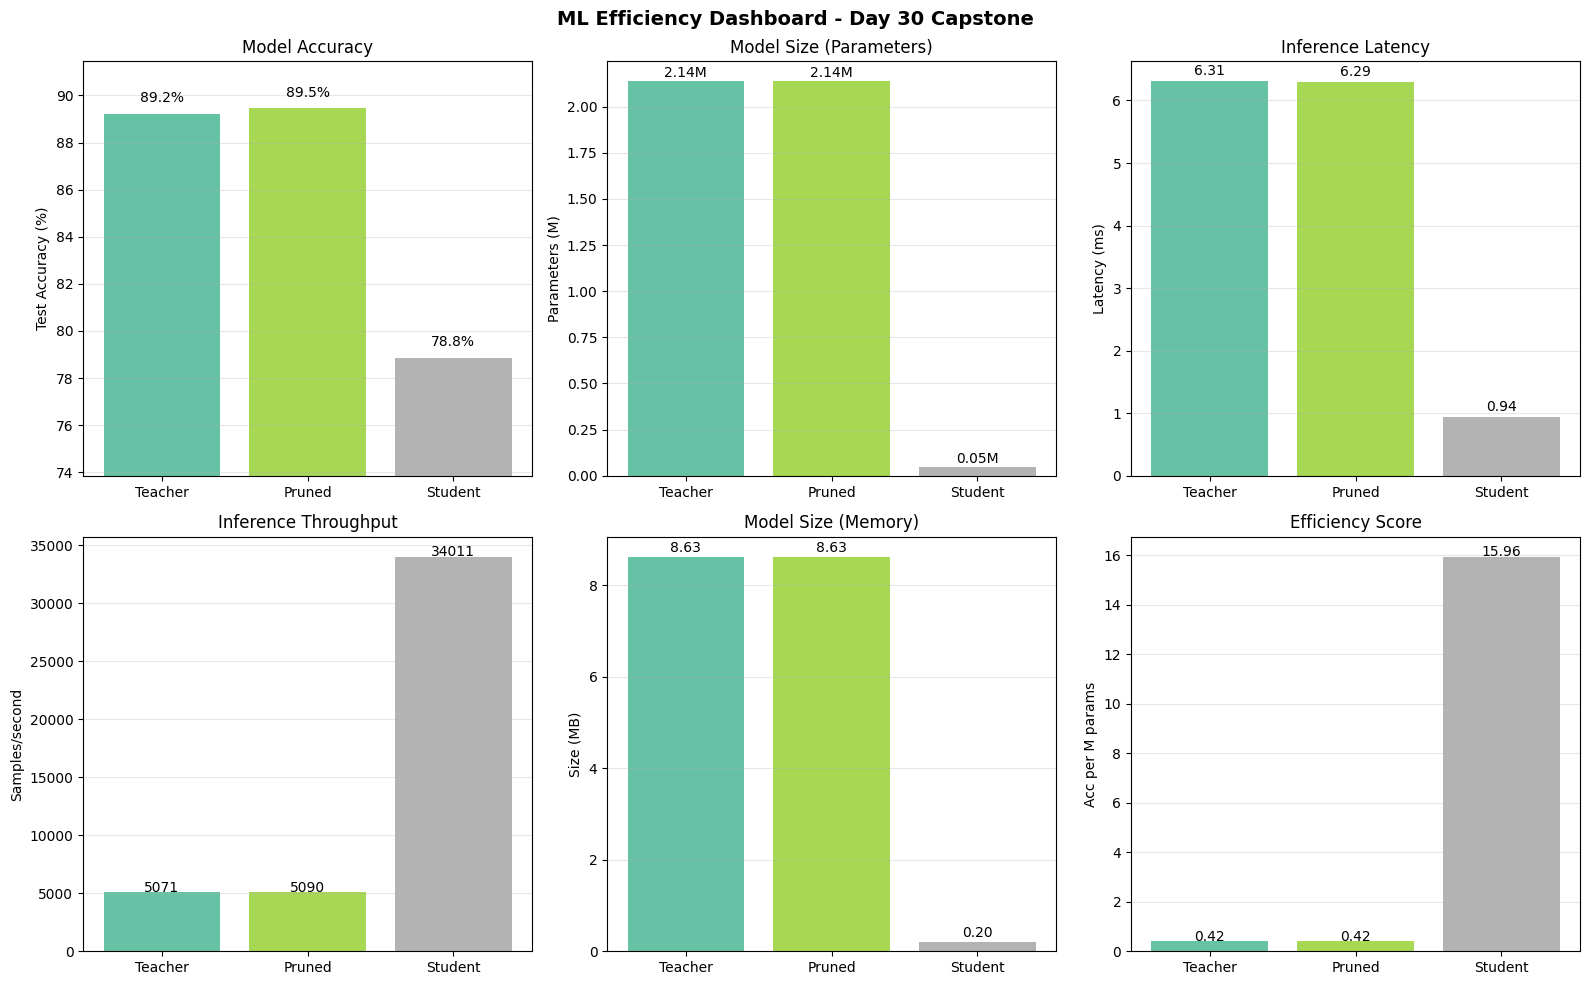

In [14]:
def plot_dashboard(analyzer: EfficiencyAnalyzer):
    """Create results dashboard."""
    results = analyzer.results
    names = list(results.keys())

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

    # 1. Accuracy
    ax = axes[0, 0]
    accs = [results[n].test_acc * 100 for n in names]
    bars = ax.bar(names, accs, color=colors)
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Model Accuracy')
    ax.set_ylim([min(accs)-5, max(accs)+2])
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, acc+0.5, f'{acc:.1f}%', ha='center', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 2. Parameters
    ax = axes[0, 1]
    params = [results[n].params / 1e6 for n in names]
    bars = ax.bar(names, params, color=colors)
    ax.set_ylabel('Parameters (M)')
    ax.set_title('Model Size (Parameters)')
    for bar, p in zip(bars, params):
        ax.text(bar.get_x()+bar.get_width()/2, p+0.02, f'{p:.2f}M', ha='center', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 3. Inference latency
    ax = axes[0, 2]
    latencies = [results[n].inference_ms for n in names]
    bars = ax.bar(names, latencies, color=colors)
    ax.set_ylabel('Latency (ms)')
    ax.set_title('Inference Latency')
    for bar, l in zip(bars, latencies):
        ax.text(bar.get_x()+bar.get_width()/2, l+0.1, f'{l:.2f}', ha='center', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 4. Throughput
    ax = axes[1, 0]
    throughputs = [results[n].throughput for n in names]
    bars = ax.bar(names, throughputs, color=colors)
    ax.set_ylabel('Samples/second')
    ax.set_title('Inference Throughput')
    for bar, t in zip(bars, throughputs):
        ax.text(bar.get_x()+bar.get_width()/2, t+50, f'{t:.0f}', ha='center', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 5. Model size (MB)
    ax = axes[1, 1]
    sizes = [results[n].model_size_mb for n in names]
    bars = ax.bar(names, sizes, color=colors)
    ax.set_ylabel('Size (MB)')
    ax.set_title('Model Size (Memory)')
    for bar, s in zip(bars, sizes):
        ax.text(bar.get_x()+bar.get_width()/2, s+0.1, f'{s:.2f}', ha='center', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    # 6. Efficiency score (accuracy / params)
    ax = axes[1, 2]
    efficiency = [results[n].test_acc * 1e6 / results[n].params for n in names]
    bars = ax.bar(names, efficiency, color=colors)
    ax.set_ylabel('Acc per M params')
    ax.set_title('Efficiency Score')
    for bar, e in zip(bars, efficiency):
        ax.text(bar.get_x()+bar.get_width()/2, e+0.01, f'{e:.2f}', ha='center', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('ML Efficiency Dashboard - Day 30 Capstone', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = plot_dashboard(system.analyzer)
plt.savefig('efficiency_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

 Final Report

In [15]:
# Generate and print final report
report = system.generate_report()
print(report)


######################################################################
#                    FINAL EFFICIENCY REPORT                    #
######################################################################

MODEL COMPARISON
Model                  Accuracy       Params   Size(MB)    Latency   Throughput
------------------------------------------------------------------------------------------
Teacher                  0.8922    2,138,058       8.63     6.31ms       5071/s
Pruned                   0.8945    2,138,058       8.63     6.29ms       5090/s
Student                  0.7885       49,418       0.20     0.94ms      34011/s

Relative to baseline:
  Pruned: +0.0023 acc, 1.0x smaller, 1.0x faster
  Student: -0.1037 acc, 43.3x smaller, 6.7x faster

SUMMARY

Teacher → Student:
  Accuracy: 0.8922 → 0.7885 (-0.1037)
  Parameters: 2,138,058 → 49,418 (43.3x reduction)
  Size: 8.63MB → 0.20MB (42.8x smaller)
  Latency: 6.31ms → 0.94ms (6.7x faster)

TECHNIQUES APPLIED

[Architecture]
  ✓ 

In [ ]:
# Save report
with open('efficiency_report.txt', 'w') as f:
    f.write(report)
print("\nReport saved to efficiency_report.txt")